<a href="https://colab.research.google.com/github/lp74428-crypto/Talleres_DataScience_Laura_Perez/blob/main/Actividad_3_Taller_EDA_Laura_Perez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

Saving Teen_Mental_Health_Dataset.csv to Teen_Mental_Health_Dataset (1).csv


In [36]:
import pandas as pd

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
display(ejercicio)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,NaN,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [19]:
#• Exploración de datos nulos, datos duplicados, cantidad de filas y columnas.

print("\nInformacion general:")
df.info()

print("\nConteo de nulos por columna:")
display(ejercicio.isna().sum())

df = df.drop_duplicates()
print("\nduplicados:",df.duplicated())



Informacion general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,1
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0



duplicados: 0       False
1       False
2       False
3       False
4       False
        ...  
1195    False
1196    False
1197    False
1198    False
1199    False
Length: 1200, dtype: bool


In [21]:
#Limpieza de datos (Pandas: dropna, fillna, replace, etc.)

#DROPNA
df = df.dropna(subset=["platform_usage"])

#REPLACE
df=df.replace("low","bajo")


In [22]:
#Filtrado y selección de datos relevantes para tu analisis

# Filto: Estrés alto (> 5) Y adicción alta (== 1)
casos_riesgo = df[(df['stress_level'] > 5) & (df['addiction_level'] == 1)]
print(casos_riesgo)

# Para el analisis solo silrven las variables de descanso y pantallas
df_sueno = df[['age', 'sleep_hours', 'screen_time_before_sleep', 'stress_level']]
print(df_sueno)

# Filtrar solo usuarios de Instagram o TikTok
plataformas_interes = ['Instagram', 'TikTok']
df_top_apps = df[df['platform_usage'].isin(plataformas_interes)]


      age  gender  daily_social_media_hours platform_usage  sleep_hours  \
18     16  female                       6.7           Both          6.8   
33     14    male                       4.1         TikTok          8.0   
34     13  female                       6.6         TikTok          7.3   
41     19    male                       1.6      Instagram          8.6   
56     18    male                       4.5         TikTok          5.0   
62     13    male                       4.3           Both          5.8   
89     18    male                       6.2      Instagram          4.1   
178    18  female                       4.5           Both          7.9   
190    16  female                       3.8         TikTok          6.0   
213    18  female                       1.9         TikTok          5.8   
226    14    male                       3.8      Instagram          5.3   
243    16  female                       7.8         TikTok          4.7   
269    19    male        

In [26]:
# Si duerme menos de 7 horas es 1 (Sí), si no es 0 (No)
df['privado_sueno'] = np.where(df['sleep_hours'] < 7.0, 1, 0)

# Rangos De 0 a 2 horas, de 2 a 5, y de 5 a 24)
limites = [0, 2, 5, 24]
etiquetas = ['Bajo (0-2h)', 'Moderado (2-5h)', 'Intenso (>5h)']

# nueva columna
df['rango_uso_redes'] = pd.cut(df['daily_social_media_hours'], bins=limites, labels=etiquetas)

In [27]:
#Agrupaciones y resúmenes (groupby)

# Agrupacion por plataforma y calculo promedio de todas las columnas numéricas
resumen_plataforma = df.groupby('platform_usage').mean(numeric_only=True)
print(resumen_plataforma)

                      age  daily_social_media_hours  sleep_hours  \
platform_usage                                                     
Both            15.956522                  4.518414     6.462916   
Instagram       15.866180                  4.559367     6.439659   
TikTok          15.964824                  4.531156     6.446231   

                screen_time_before_sleep  academic_performance  \
platform_usage                                                   
Both                            1.745269              2.975192   
Instagram                       1.712409              2.995499   
TikTok                          1.764322              3.000025   

                physical_activity  stress_level  anxiety_level  \
platform_usage                                                   
Both                     1.020460      5.549872       5.488491   
Instagram                1.040389      5.498783       5.669100   
TikTok                   0.981910      5.288945       5.748744  

In [32]:
# 1-Los usuarios de como TikTok o Instagram pasan significativamente más horas conectados o muestran niveles de adicción más altos en comparación con las demás apps?

df.groupby("platform_usage")[["daily_social_media_hours", "addiction_level"]].mean()

# 2-Cómo afecta el tiempo de pantalla antes de dormir a la calidad del descanso?

df.groupby("gender")[["screen_time_before_sleep", "sleep_hours"]].mean()

# 3-El uso intensivo de redes sociales está asociado con un menor rendimiento académico?
df.groupby("rango_uso_redes")["academic_performance"].mean()

# 4-Los estudiantes que duermen menos de 7 horas tienen niveles de estrés y ansiedad más altos que los que duermen bien?

df.groupby("privado_sueno")[["stress_level", "anxiety_level"]].mean()

# 5-¿Qué combinación de factores caracteriza a los casos con etiquetas de depresión alta?

df.groupby("depression_label")[["daily_social_media_hours", "sleep_hours", "physical_activity"]].mean()

#Respuesta: Los casos en que el nivel de depresion es mayor pasan las horas en las redes sociales con una media de 6 horas y tienen menos horas de sueño


/tmp/ipykernel_4875/1772971017.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("rango_uso_redes")["academic_performance"].mean()


,daily_social_media_hours,sleep_hours,physical_activity
depression_label,,,
0,4.478785,6.494183,1.016168
1,6.719355,4.761290,0.951613


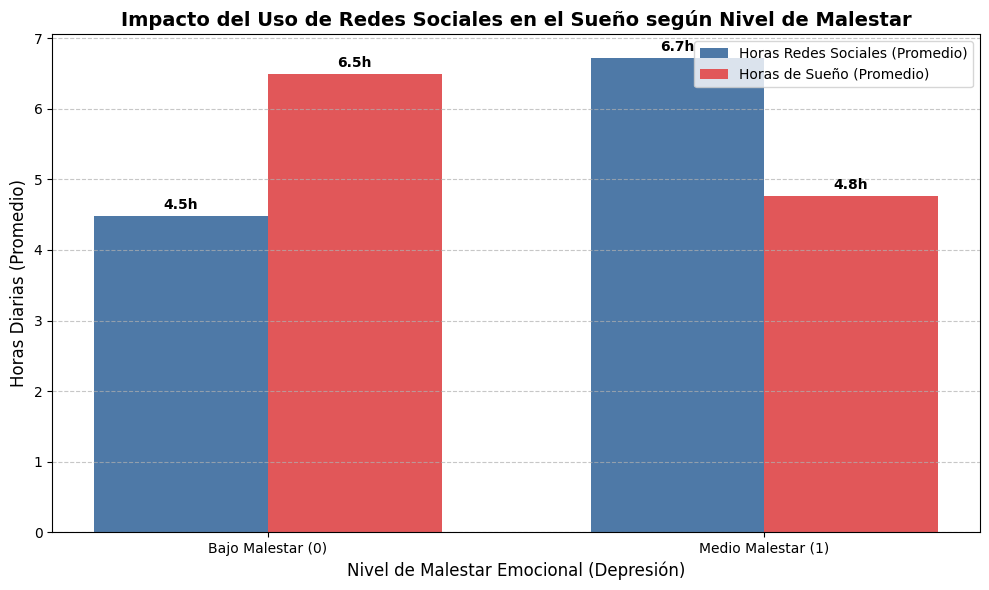

In [37]:
#Gráfica

data = {
    'daily_social_media_hours': [4.4787, 6.7193],
    'sleep_hours': [6.4941, 4.7612]
}

df_resumen = pd.DataFrame(data, index=['Bajo Malestar (0)', 'Medio Malestar (1)'])

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_resumen.index))
width = 0.35

rects1 = ax.bar(x - width/2, df_resumen['daily_social_media_hours'], width,
                label='Horas Redes Sociales (Promedio)', color='#4e79a7')

rects2 = ax.bar(x + width/2, df_resumen['sleep_hours'], width,
                label='Horas de Sueño (Promedio)', color='#e15759')

ax.set_title('Impacto del Uso de Redes Sociales en el Sueño según Nivel de Malestar', fontsize=14, fontweight='bold')
ax.set_ylabel('Horas Diarias (Promedio)', fontsize=12)
ax.set_xlabel('Nivel de Malestar Emocional (Depresión)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(df_resumen.index)

ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    """Agrega una etiqueta de texto sobre cada barra, mostrando su altura."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}h',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()